# scConcept Tutorial: Developmental Potency Inference and Perturbation

This tutorial demonstrates how to use **scConcept** to infer developmental potency programs and perform in silico perturbation analysis, given precomputed topic gene lists from a trained topic model (e.g., ECRTM).

---

## Prerequisites

Before running this tutorial, you should have already:

1. Trained a topic model on your single-cell RNA-seq dataset using **ECRTM**  
2. Saved the topic gene lists (e.g., top genes per topic)  

---

## What this tutorial does

Starting from precomputed topic gene lists, this tutorial walks through:

1. **Loading topic gene lists** generated by ECRTM  
2. **Distilling developmental potency programs** using an LLM  
3. **Assigning each cell to a potency state** based on concept gene programs  
4. **Comparing predicted potency with reference annotations**  
5. **Performing in silico perturbation** to simulate developmental transitions  
6. **Visualizing perturbation effects** in a shared UMAP space  

---

## Expected outcome

By the end of this tutorial, you will obtain:

- A set of **developmental potency programs**  
- **Cell-level potency annotations**  
- Quantitative evaluation of **potency prediction performance**  
- A visualization showing **cell state transitions after perturbation**  

---

## Note

This tutorial assumes that the topic model training step has already been completed.  
Developmental potency is treated as a **continuum**, and some potency levels may not be present in every dataset.

---

## Overview

This tutorial extends scConcept from static interpretation to **dynamic analysis of cellular developmental states**,  
enabling concept-level modeling of **potency and cell state transitions**.

In [ ]:
import numpy as np
from types import SimpleNamespace
from pathlib import Path
import sys

# =========================================================
# Project setup for the tutorial notebook
# =========================================================

PROJECT_ROOT = Path.cwd().parent
ECRTM_PATH = PROJECT_ROOT / "ECRTM"
sys.path.append(str(ECRTM_PATH))

from singlecell_dataset import SingleCellDataset

# =========================================================
# User-defined configuration
# =========================================================

dataset_name = "Mouse_neurogenesis_10x_cytotrace2"
data_dir = PROJECT_ROOT / "Datasets"
batch_size = 512

# =========================================================
# Build configuration namespace
# =========================================================

config = SimpleNamespace(
    dataset=dataset_name,
    batch_size=batch_size,
    data_dir=str(data_dir),
)

# =========================================================
# Load dataset
# =========================================================

dataset = SingleCellDataset(
    dataset_name=config.dataset,
    batch_size=config.batch_size,
    data_dir=config.data_dir,
)

train_matrix = dataset.train_data
test_matrix = dataset.test_data
train_labels = dataset.train_labels
test_labels = dataset.test_labels
gene_names = dataset.gene_names
num_genes = dataset.n_genes

# =========================================================
# Sanity check
# =========================================================

print(f"Train data shape: {train_matrix.shape}")
print(f"Test data shape: {test_matrix.shape}")
print(f"Train labels shape: {np.shape(train_labels)}")
print(f"Test labels shape: {np.shape(test_labels)}")
print(f"Number of genes: {num_genes}")
print(f"First 10 genes: {gene_names[:10]}")

===> Train size: 14835
===> Test size: 14835
===> Number of genes: 10000
===> Avg expression per cell: 1261.807
===> Number of labels: 8
Train data shape: torch.Size([14835, 10000])
Test data shape: torch.Size([14835, 10000])
Train labels shape: (1, 14835)
Test labels shape: (1, 14835)
Number of genes: 10000
First 10 genes: ['XKR4', 'GM1992', 'GM19938', 'RP1', 'GM37323', 'RGS20', '4732440D04RIK', 'ALKAL1', 'ST18', 'GM26901']


In [51]:
from pathlib import Path

# =========================================================
# Function: load topic gene lists
# =========================================================

def load_topic_genes(topic_file):
    """
    Load topic gene lists from a text file.

    Each line corresponds to one topic, where genes are separated by spaces.

    Parameters
    ----------
    topic_file : str or Path
        Path to the topic gene file.

    Returns
    -------
    list[list[str]]
        A list of topics, where each topic is a list of gene names.
    """
    topic_gene_lists = []

    with open(topic_file, "r", encoding="utf-8") as f:
        for line in f:
            genes = line.strip().split()
            topic_gene_lists.append(genes)

    return topic_gene_lists


# =========================================================
# Automatically construct topic file path
# =========================================================

num_topics = 50
seed = 1
epoch = 500

topic_dir = (
    PROJECT_ROOT
    / "ECRTM"
    / "output"
    / "topics"
    / f"{dataset_name}_K{num_topics}_seed{seed}"
)

topic_file = topic_dir / f"epoch{epoch}_top_genes.txt"

# Check file existence
if not topic_file.exists():
    raise FileNotFoundError(f"Topic file not found: {topic_file}")

# =========================================================
# Load topic gene lists
# =========================================================

topic_gene_lists = load_topic_genes(topic_file)

# =========================================================
# Sanity check
# =========================================================

print(f"Topic file: {topic_file}")
print(f"Number of topics: {len(topic_gene_lists)}")
print(f"Top 20 genes in Topic 0: {topic_gene_lists[0][:20]}")

Topic file: /home/mcb/users/hchen26/method/textgrad/LLM-ITL-main/scConcept_github/ECRTM/output/topics/Mouse_neurogenesis_10x_cytotrace2_K50_seed1/epoch500_top_genes.txt
Number of topics: 50
Top 20 genes in Topic 0: ['CELA1', 'CD33', 'GM29676', 'LAPTM5', 'GM43729', 'GM15674', 'VMN2R58', 'GM16180', 'GM21188', 'PRRXL1', 'RGS21', 'OLFR921', 'FOXI3', 'GM16095', 'SERPINB5', 'SPI1', 'GM31026', 'GM13264', 'MUC5B', '0610033M10RIK']


In [53]:
import json
from pathlib import Path
from openai import OpenAI

# =========================================================
# Convert topic gene lists into JSON payload
# =========================================================
# Each topic is represented by:
# - topic_id: topic index
# - genes: top genes of that topic
#
# Here we reuse the pre-extracted topic_gene_lists loaded above.

topics_payload = [
    {
        "topic_id": f"topic_{topic_id}",
        "genes": topic_gene_lists[topic_id]
    }
    for topic_id in range(len(topic_gene_lists))
]

topics_json_str = json.dumps({"topics": topics_payload}, indent=2)

# =========================================================
# Build the developmental potency distillation prompt
# =========================================================
# The LLM is asked to identify developmental potency-related
# gene programs from pre-extracted topic gene lists.
#
# The six predefined potency categories are:
# Toti., Pluri., Multi., Oligo., Uni., and Diff.

potency_program_prompt = f"""
You are given topics derived from a neural topic model on single-cell RNA-seq data.

Each topic includes ONLY:
- A list of the top 100 genes for that topic,
  sorted from highest weight to lowest weight in the model.

Here are all topics (JSON list):
{topics_json_str}

------------------------------------------------------------
TASK: Developmental Potency Program Distillation
------------------------------------------------------------

Your goal is to identify biologically coherent gene programs that reflect
DIFFERENT LEVELS OF CELLULAR DEVELOPMENTAL POTENCY.

You must analyze ONLY the provided top-100 gene lists from the topics.
No external knowledge, marker lists, or invented genes are allowed.

The target developmental potency categories are EXACTLY the following six:

1. Toti.  (totipotent)
2. Pluri. (pluripotent)
3. Multi. (multipotent)
4. Oligo. (oligopotent)
5. Uni.   (unipotent)
6. Diff.  (differentiated)

IMPORTANT:
- These categories define an INTERPRETIVE FRAMEWORK, not guaranteed labels.
- Some categories MAY NOT be detectable in the provided topics.
- If no coherent gene program exists for a category, you MUST output an empty gene list for that category.

------------------------------------------------------------
BIOLOGICAL INTERPRETATION GUIDELINES
------------------------------------------------------------

You should infer developmental potency ONLY from gene patterns such as:
- stemness vs lineage restriction,
- transcriptional plasticity vs functional specialization,
- progenitor-like vs terminal differentiation programs,
- broad developmental regulators vs lineage-specific effector genes.

DO NOT:
- assume cell types,
- assume developmental time points,
- use known CytoTRACE markers explicitly,
- force topics into categories if evidence is weak.

A gene program must show CONSISTENT biological signals across one or more topics
to be assigned to a potency category.

------------------------------------------------------------
PROGRAM CONSTRUCTION RULES
------------------------------------------------------------

For EACH of the six potency categories:

- Identify zero or more topics whose top genes SUPPORT that potency level.
- Extract a representative gene set from those topics.

Gene selection rules:
- Genes MUST come ONLY from the union of genes in the selected source topics.
- Prefer genes that are:
  * highly ranked in their topics,
  * recurrent across topics,
  * biologically consistent with the inferred potency level.
- DO NOT invent gene names.
- Gene lists may have VARIABLE length (including empty lists).

------------------------------------------------------------
OUTPUT FORMAT (STRICT JSON)
------------------------------------------------------------

Respond ONLY with a valid JSON object in EXACTLY the following format:

{{
  "concepts": [
    {{
      "name": "Toti.",
      "genes": ["GENE1", "GENE2", "..."],
      "source_topics": ["topic_1", "topic_7"]
    }},
    {{
      "name": "Pluri.",
      "genes": [],
      "source_topics": []
    }},
    {{
      "name": "Multi.",
      "genes": ["GENE_A", "GENE_B"],
      "source_topics": ["topic_3"]
    }},
    {{
      "name": "Oligo.",
      "genes": ["GENE_X", "GENE_Y"],
      "source_topics": ["topic_5", "topic_9"]
    }},
    {{
      "name": "Uni.",
      "genes": ["GENE_M", "GENE_N"],
      "source_topics": ["topic_12"]
    }},
    {{
      "name": "Diff.",
      "genes": ["GENE_D1", "GENE_D2"],
      "source_topics": ["topic_15", "topic_18"]
    }}
  ]
}}

------------------------------------------------------------
ABSOLUTE RULES
------------------------------------------------------------

- DO NOT output anything outside the JSON object.
- DO NOT add code fences (no ```json).
- DO NOT invent genes or modify gene symbols.
- DO NOT force assignments when evidence is weak.
- Empty gene lists are VALID and encouraged when appropriate.
- Interpret potency as a CONTINUUM, not discrete cell types.
"""

# =========================================================
# Call the OpenAI API to generate developmental potency concepts
# =========================================================
# Make sure your OPENAI_API_KEY environment variable is set
# before running this step.
#
# Do NOT hard-code your API key in the tutorial.

client = OpenAI(api_key="")


completion = client.chat.completions.create(
    model="gpt-5",
    seed=1,
    messages=[
        {"role": "system", "content": "You are an expert in single-cell biology."},
        {"role": "user", "content": potency_program_prompt}
    ]
)

response_text = completion.choices[0].message.content

# =========================================================
# Parse the LLM output
# =========================================================
# The model is expected to return a JSON object with a
# top-level key called "concepts".

concept_result = json.loads(response_text)
potency_concepts = concept_result["concepts"]

print(f"Number of potency concepts generated: {len(potency_concepts)}")
print(f"First potency concept name: {potency_concepts[0]['name']}")
print(f"Number of genes in first concept: {len(potency_concepts[0]['genes'])}")

# =========================================================
# Save the generated developmental potency concepts
# =========================================================
# Concepts are saved to:
# Results/<dataset_name>/gpt5_<dataset_name>_potency_concepts.json

results_dir = PROJECT_ROOT / "Results" / dataset_name
results_dir.mkdir(parents=True, exist_ok=True)

output_file = results_dir / f"gpt5_{dataset_name}_potency_concepts.json"

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(potency_concepts, f, indent=2, ensure_ascii=False)

print(f"Saved developmental potency concepts to: {output_file}")

Number of potency concepts generated: 6
First potency concept name: Toti.
Number of genes in first concept: 0
Saved developmental potency concepts to: /home/mcb/users/hchen26/method/textgrad/LLM-ITL-main/scConcept_github/Results/Mouse_neurogenesis_10x_cytotrace2/gpt5_Mouse_neurogenesis_10x_cytotrace2_potency_concepts.json


In [54]:
import numpy as np

# =========================================================
# Utility functions for developmental potency assignment
# =========================================================

def build_gene_index(gene_names):
    """
    Create a mapping from gene name to column index.

    Parameters
    ----------
    gene_names : list-like
        Ordered list of gene names.

    Returns
    -------
    dict
        Dictionary mapping gene name to column index.
    """
    return {str(gene): idx for idx, gene in enumerate(gene_names)}


def truncate_concept_genes(concepts, top_k):
    """
    Keep only the top-k genes for each developmental potency concept.

    Parameters
    ----------
    concepts : list[dict]
        List of concept dictionaries. Each concept should contain at least:
        - "name"
        - "genes"
        - optional "source_topics"
    top_k : int
        Number of top genes to retain.

    Returns
    -------
    list[dict]
        Updated concept list with truncated gene sets.
    """
    truncated_concepts = []

    for concept in concepts:
        truncated_concepts.append(
            {
                "name": concept["name"],
                "genes": concept["genes"][:top_k],
                "source_topics": concept.get("source_topics", [])
            }
        )

    return truncated_concepts


def assign_cells_to_potency_concepts(concepts, expression_matrix, gene_to_index):
    """
    Assign each cell to the developmental potency concept with the highest score.

    For each potency concept, the cell-level score is computed as the summed
    expression of the concept genes detected in the dataset.

    Parameters
    ----------
    concepts : list[dict]
        List of developmental potency concept dictionaries. Each concept should
        contain:
        - "name"
        - "genes"
    expression_matrix : torch.Tensor
        Cell-by-gene expression matrix of shape (num_cells, num_genes).
    gene_to_index : dict
        Mapping from gene name to column index.

    Returns
    -------
    score_matrix : np.ndarray
        Matrix of shape (num_cells, num_concepts).
    concept_names : list[str]
        Names of all developmental potency concepts.
    predicted_labels : list[str]
        Predicted potency concept label for each cell.
    """
    expression_array = expression_matrix.detach().cpu().numpy().astype(float)

    concept_names = [concept["name"] for concept in concepts]
    num_cells = expression_array.shape[0]
    num_concepts = len(concepts)

    score_matrix = np.zeros((num_cells, num_concepts), dtype=float)

    for concept_index, concept in enumerate(concepts):
        concept_genes = concept["genes"]

        gene_indices = [
            gene_to_index[gene]
            for gene in concept_genes
            if gene in gene_to_index
        ]

        if len(gene_indices) == 0:
            continue

        score_matrix[:, concept_index] = expression_array[:, gene_indices].sum(axis=1)

    predicted_indices = np.argmax(score_matrix, axis=1)
    predicted_labels = [concept_names[idx] for idx in predicted_indices]

    return score_matrix, concept_names, predicted_labels


# =========================================================
# Example usage: developmental potency assignment on the test set
# =========================================================

gene_to_index = build_gene_index(gene_names)

top_k = 100
top_k_potency_concepts = truncate_concept_genes(
    potency_concepts,
    top_k=top_k
)

potency_score_matrix, potency_concept_names, predicted_potency_labels = (
    assign_cells_to_potency_concepts(
        top_k_potency_concepts,
        test_matrix,
        gene_to_index
    )
)

print(f"Potency score matrix shape: {potency_score_matrix.shape}")
print(f"Potency concepts: {potency_concept_names}")
print(f"Example predicted potency labels: {predicted_potency_labels[:10]}")


Potency score matrix shape: (14835, 6)
Potency concepts: ['Toti.', 'Pluri.', 'Multi.', 'Oligo.', 'Uni.', 'Diff.']
Example predicted potency labels: ['Diff.', 'Diff.', 'Diff.', 'Diff.', 'Diff.', 'Diff.', 'Diff.', 'Diff.', 'Diff.', 'Diff.']


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import kendalltau

# =========================================================
# Load developmental potency annotations
# =========================================================
# The potency annotation file is assumed to be prepared beforehand.
# Here we keep the existing annotation path unchanged.

base = ""
potency_path = base + dataset_name + "_cell_Potency.csv"

df_potency = pd.read_csv(potency_path, index_col=0)

print(f"Potency annotation file: {potency_path}")
print(f"Potency annotation shape: {df_potency.shape}")
print(df_potency.head())


Potency annotation file: /home/mcb/users/hchen26/data/scDATA/Mouse_neurogenesis_10x_cytotrace2_cell_Potency.csv
Potency annotation shape: (14835, 1)
                        potency_annotation
sort_AAACCCAAGACCTTTG_1     Differentiated
sort_AAACCCAAGAGCAAGA_1     Differentiated
sort_AAACCCAAGAGCATCG_1     Differentiated
sort_AAACCCAAGATTTGCC_1     Differentiated
sort_AAACCCAAGCGGGTTA_1     Differentiated


In [57]:
# =========================================================
# Prepare valid developmental potency concepts
# =========================================================
# Some potency concepts may contain no genes detected in the dataset.
# These concepts should not be selected during prediction.

num_matched_genes = np.array([
    len([gene for gene in concept["genes"] if gene in gene_to_index])
    for concept in top_k_potency_concepts
])

valid_mask = num_matched_genes > 0

print("Number of matched genes per potency concept:")
for name, n_genes, is_valid in zip(
    potency_concept_names,
    num_matched_genes,
    valid_mask
):
    print(f"{name}: {n_genes} genes, valid={is_valid}")


Number of matched genes per potency concept:
Toti.: 0 genes, valid=False
Pluri.: 0 genes, valid=False
Multi.: 35 genes, valid=True
Oligo.: 30 genes, valid=True
Uni.: 23 genes, valid=True
Diff.: 37 genes, valid=True


In [58]:
# =========================================================
# Predict developmental potency labels
# =========================================================
# The prediction is based on the highest-scoring valid potency concept.
# Concepts without matched genes are masked out and cannot be selected.

scores_for_prediction = potency_score_matrix.copy()
scores_for_prediction[:, ~valid_mask] = -np.inf

potency_order = [
    "Totipotent",
    "Pluripotent",
    "Multipotent",
    "Oligopotent",
    "Unipotent",
    "Differentiated"
]

predicted_potency_indices = scores_for_prediction.argmax(axis=1)
predicted_potency = np.array([
    potency_order[index] for index in predicted_potency_indices
])

print(f"Number of predicted cells: {len(predicted_potency)}")
print(f"Example predicted potency labels: {predicted_potency[:10]}")


Number of predicted cells: 14835
Example predicted potency labels: ['Differentiated' 'Differentiated' 'Differentiated' 'Differentiated'
 'Differentiated' 'Differentiated' 'Differentiated' 'Differentiated'
 'Differentiated' 'Differentiated']


In [59]:
# =========================================================
# Compare predicted potency labels with reference annotations
# =========================================================
# Here we use the precomputed potency_annotation column as reference.

true_potency = df_potency["potency_annotation"]

accuracy = accuracy_score(true_potency, predicted_potency)
f1_macro = f1_score(true_potency, predicted_potency, average="macro")
f1_weighted = f1_score(true_potency, predicted_potency, average="weighted")

print("Accuracy:", accuracy)
print("F1_macro:", f1_macro)
print("F1_weighted:", f1_weighted)


Accuracy: 0.6951129086619481
F1_macro: 0.42171519229432997
F1_weighted: 0.7797375306574493


In [60]:
# =========================================================
# Evaluate ordinal agreement using Kendall's tau
# =========================================================
# Developmental potency is treated as an ordered continuum:
# lower values indicate higher developmental potential.

potency_to_numeric = {
    "Totipotent": 1,
    "Pluripotent": 2,
    "Multipotent": 3,
    "Oligopotent": 4,
    "Unipotent": 5,
    "Differentiated": 6,
}

true_potency_numeric = true_potency.map(potency_to_numeric).values
predicted_potency_numeric = np.array([
    potency_to_numeric[label] for label in predicted_potency
])

kendall_tau, kendall_pvalue = kendalltau(
    predicted_potency_numeric,
    true_potency_numeric
)

print("Kendall_tau:", kendall_tau)
print("p-value:", kendall_pvalue)

Kendall_tau: 0.6859649099699021
p-value: 0.0


In [61]:
import numpy as np
import scanpy as sc
import anndata as ad

# =========================================================
# Utility function: get gene indices
# =========================================================

def get_gene_indices(var_names, genes):
    """
    Find indices of selected genes in an AnnData object.

    Parameters
    ----------
    var_names : list-like
        Gene names in the AnnData object.
    genes : list[str]
        Genes to search for.

    Returns
    -------
    indices : np.ndarray
        Column indices of genes found in var_names.
    genes_found : list[str]
        Genes successfully matched.
    genes_missing : list[str]
        Genes not found in var_names.
    """
    gene_to_index = {str(gene): idx for idx, gene in enumerate(var_names)}

    genes_found = [gene for gene in genes if gene in gene_to_index]
    indices = np.array(
        [gene_to_index[gene] for gene in genes_found],
        dtype=int
    )

    genes_missing = sorted(set(genes) - set(genes_found))

    return indices, genes_found, genes_missing


# =========================================================
# Utility function: perturb selected cells
# =========================================================

def perturb_cells_in_adata(
    adata_sub,
    add_genes,
    remove_genes,
    add_fold=4.0
):
    """
    Perturb selected cells in an AnnData object.

    The perturbation simulates a transition by:
    - increasing expression of add_genes by add_fold
    - decreasing expression of remove_genes by 1 / add_fold

    Parameters
    ----------
    adata_sub : AnnData
        AnnData object containing only the cells to perturb.
    add_genes : list[str]
        Genes to up-regulate.
    remove_genes : list[str]
        Genes to down-regulate.
    add_fold : float
        Fold-change used for perturbation.

    Returns
    -------
    AnnData
        Perturbed AnnData object.
    """
    adata_perturbed = adata_sub.copy()

    add_indices, add_genes_found, add_genes_missing = get_gene_indices(
        adata_perturbed.var_names,
        add_genes
    )

    remove_indices, remove_genes_found, remove_genes_missing = get_gene_indices(
        adata_perturbed.var_names,
        remove_genes
    )

    print(f"Perturbing {adata_perturbed.n_obs} cells")
    print(f"ADD genes found: {len(add_genes_found)} / {len(add_genes)}")
    print(f"REMOVE genes found: {len(remove_genes_found)} / {len(remove_genes)}")

    if len(add_genes_missing) > 0:
        print(
            "Missing ADD genes:",
            add_genes_missing[:20],
            "..." if len(add_genes_missing) > 20 else ""
        )

    if len(remove_genes_missing) > 0:
        print(
            "Missing REMOVE genes:",
            remove_genes_missing[:20],
            "..." if len(remove_genes_missing) > 20 else ""
        )

    expression_array = np.array(adata_perturbed.X, copy=True)

    if add_indices.size > 0:
        expression_array[:, add_indices] *= add_fold

    if remove_indices.size > 0:
        expression_array[:, remove_indices] *= 1.0 / add_fold

    adata_perturbed.X = expression_array

    return adata_perturbed

In [62]:
# =========================================================
# Build control, reference, and perturbed AnnData objects
# =========================================================

def build_developmental_perturbation_adatas(
    adata,
    add_genes,
    remove_genes,
    label_col="potency_annotation",
    source_label="Multipotent",
    target_label="Differentiated",
    add_fold=4.0,
    batch_col="batch",
):
    """
    Build AnnData objects for developmental potency perturbation.

    This function constructs:
    - source cells: original cells from the starting potency state
    - target cells: original cells from the target potency state
    - perturbed source cells: source cells after in silico perturbation
    - reference AnnData: source + target
    - all AnnData: source + target + perturbed source

    Parameters
    ----------
    adata : AnnData
        Original AnnData object.
    add_genes : list[str]
        Genes to up-regulate during perturbation.
    remove_genes : list[str]
        Genes to down-regulate during perturbation.
    label_col : str
        Column in adata.obs storing potency annotations.
    source_label : str
        Starting potency state.
    target_label : str
        Target potency state.
    add_fold : float
        Fold-change used for perturbation.
    batch_col : str
        Column used to label original and perturbed groups.

    Returns
    -------
    tuple
        source_adata, target_adata, perturbed_source_adata,
        reference_adata, all_adata, reference_labels
    """
    source_mask = (adata.obs[label_col].astype(str) == source_label).values
    target_mask = (adata.obs[label_col].astype(str) == target_label).values

    if source_mask.sum() == 0:
        raise ValueError(f"No cells with {label_col} == '{source_label}'")

    if target_mask.sum() == 0:
        raise ValueError(f"No cells with {label_col} == '{target_label}'")

    source_adata = adata[source_mask].copy()
    target_adata = adata[target_mask].copy()

    perturbed_source_adata = perturb_cells_in_adata(
        source_adata,
        add_genes=add_genes,
        remove_genes=remove_genes,
        add_fold=add_fold
    )

    source_adata.obs[batch_col] = "Control"
    target_adata.obs[batch_col] = "Target"
    perturbed_source_adata.obs[batch_col] = "In silico perturbed"

    for subset_adata in (source_adata, target_adata, perturbed_source_adata):
        subset_adata.obs[batch_col] = subset_adata.obs[batch_col].astype("category")

    reference_adata = ad.concat(
        [source_adata, target_adata],
        label="batch_index"
    )
    reference_adata.obs[batch_col] = reference_adata.obs[batch_col].astype("category")

    all_adata = ad.concat(
        [source_adata, target_adata, perturbed_source_adata],
        label="batch_index"
    )
    all_adata.obs[batch_col] = all_adata.obs[batch_col].astype("category")

    reference_labels = (
        ["Control"] * source_adata.n_obs
        + ["Target"] * target_adata.n_obs
    )

    return (
        source_adata,
        target_adata,
        perturbed_source_adata,
        reference_adata,
        all_adata,
        reference_labels
    )

In [63]:
import anndata as ad
import pandas as pd
import numpy as np

# =========================================================
# Convert dataset to AnnData format
# =========================================================
# This step converts the matrix-based dataset into AnnData,
# which is required for downstream perturbation and visualization.

# expression matrix
X = test_matrix.detach().cpu().numpy()

# gene names
var = pd.DataFrame(index=gene_names)

# cell metadata（这里先空，后面再加 potency）
obs = pd.DataFrame(index=[f"cell_{i}" for i in range(X.shape[0])])

adata = ad.AnnData(X=X, obs=obs, var=var)

print(adata)

# =========================================================
# Add developmental potency annotations
# =========================================================

adata.obs["potency_annotation"] = df_potency["potency_annotation"].values

print(adata.obs["potency_annotation"].value_counts())

AnnData object with n_obs × n_vars = 14835 × 10000
potency_annotation
Differentiated    11216
Multipotent        2544
Unipotent          1075
Name: count, dtype: int64


In [39]:
# =========================================================
# Example usage: perturb Multipotent cells toward Differentiated cells
# =========================================================
# In this example:
# - Differentiated concept genes are up-regulated.
# - Multipotent concept genes are down-regulated.
#
# The potency concept order is:
# 0: Toti.
# 1: Pluri.
# 2: Multi.
# 3: Oligo.
# 4: Uni.
# 5: Diff.

source_concept_index = 2      # Multi.
target_concept_index = 5      # Diff.

add_genes = top_k_potency_concepts[target_concept_index]["genes"]
remove_genes = top_k_potency_concepts[source_concept_index]["genes"]

(
    adata_source,
    adata_target,
    adata_perturbed,
    adata_reference,
    adata_all,
    reference_labels
) = build_developmental_perturbation_adatas(
    adata,
    add_genes=add_genes,
    remove_genes=remove_genes,
    label_col="potency_annotation",
    source_label="Multipotent",
    target_label="Differentiated",
    add_fold=64.0,
    batch_col="batch",
)

print("Source AnnData:", adata_source)
print("Target AnnData:", adata_target)
print("Perturbed AnnData:", adata_perturbed)
print("Reference AnnData:", adata_reference)
print("All AnnData:", adata_all)
print("Reference labels length:", len(reference_labels))

Perturbing 2544 cells
ADD genes found: 44 / 44
REMOVE genes found: 34 / 34
Source AnnData: AnnData object with n_obs × n_vars = 2544 × 10000
    obs: 'potency_annotation', 'batch'
Target AnnData: AnnData object with n_obs × n_vars = 11216 × 10000
    obs: 'potency_annotation', 'batch'
Perturbed AnnData: AnnData object with n_obs × n_vars = 2544 × 10000
    obs: 'potency_annotation', 'batch'
Reference AnnData: AnnData object with n_obs × n_vars = 13760 × 10000
    obs: 'potency_annotation', 'batch', 'batch_index'
All AnnData: AnnData object with n_obs × n_vars = 16304 × 10000
    obs: 'potency_annotation', 'batch', 'batch_index'
Reference labels length: 13760


/home/mcb/users/hchen26/.conda/envs/textgrad-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [64]:
import numpy as np
import scanpy as sc
import anndata as ad

# =========================================================
# Utility function: get gene indices
# =========================================================

def get_gene_indices(var_names, genes):
    """
    Find indices of selected genes in an AnnData object.
    """
    gene_to_index = {str(gene): idx for idx, gene in enumerate(var_names)}

    genes_found = [gene for gene in genes if gene in gene_to_index]
    indices = np.array([gene_to_index[gene] for gene in genes_found], dtype=int)

    genes_missing = sorted(set(genes) - set(genes_found))

    return indices, genes_found, genes_missing


# =========================================================
# Utility function: perturb selected cells
# =========================================================

def perturb_cells_in_adata(
    adata_sub,
    add_genes,
    remove_genes,
    add_fold=4.0
):
    """
    Perturb selected cells in an AnnData object.

    The perturbation simulates a transition by:
    - increasing expression of add_genes by add_fold
    - decreasing expression of remove_genes by 1 / add_fold

    Parameters
    ----------
    adata_sub : AnnData
        AnnData object containing only the cells to perturb.
    add_genes : list[str]
        Genes to up-regulate.
    remove_genes : list[str]
        Genes to down-regulate.
    add_fold : float
        Fold-change used for perturbation.

    Returns
    -------
    AnnData
        Perturbed AnnData object.
    """
    adata_perturbed = adata_sub.copy()

    add_indices, add_genes_found, add_genes_missing = get_gene_indices(
        adata_perturbed.var_names,
        add_genes
    )

    remove_indices, remove_genes_found, remove_genes_missing = get_gene_indices(
        adata_perturbed.var_names,
        remove_genes
    )

    print(f"Perturbing {adata_perturbed.n_obs} cells")
    print(f"ADD genes found: {len(add_genes_found)} / {len(add_genes)}")
    print(f"REMOVE genes found: {len(remove_genes_found)} / {len(remove_genes)}")

    if len(add_genes_missing) > 0:
        print(
            "Missing ADD genes:",
            add_genes_missing[:20],
            "..." if len(add_genes_missing) > 20 else ""
        )

    if len(remove_genes_missing) > 0:
        print(
            "Missing REMOVE genes:",
            remove_genes_missing[:20],
            "..." if len(remove_genes_missing) > 20 else ""
        )

    expression_array = np.array(adata_perturbed.X, copy=True)

    if add_indices.size > 0:
        expression_array[:, add_indices] *= add_fold

    if remove_indices.size > 0:
        expression_array[:, remove_indices] *= 1.0 / add_fold

    adata_perturbed.X = expression_array

    return adata_perturbed


# =========================================================
# Build control, target, and perturbed AnnData objects
# =========================================================

def build_developmental_perturbation_adatas(
    adata,
    add_genes,
    remove_genes,
    label_col="potency_annotation",
    source_label="Multipotent",
    target_label="Differentiated",
    add_fold=4.0,
    batch_col="batch",
):
    """
    Build AnnData objects for developmental potency perturbation.

    This function constructs:
    - source cells: original cells from the starting potency state
    - target cells: original cells from the target potency state
    - perturbed source cells: source cells after in silico perturbation
    - reference AnnData: source + target
    - all AnnData: source + target + perturbed source
    """
    source_mask = (adata.obs[label_col].astype(str) == source_label).values
    target_mask = (adata.obs[label_col].astype(str) == target_label).values

    if source_mask.sum() == 0:
        raise ValueError(f"No cells with {label_col} == '{source_label}'")

    if target_mask.sum() == 0:
        raise ValueError(f"No cells with {label_col} == '{target_label}'")

    source_adata = adata[source_mask].copy()
    target_adata = adata[target_mask].copy()

    perturbed_source_adata = perturb_cells_in_adata(
        source_adata,
        add_genes=add_genes,
        remove_genes=remove_genes,
        add_fold=add_fold
    )

    source_adata.obs[batch_col] = "Control"
    target_adata.obs[batch_col] = "Target"
    perturbed_source_adata.obs[batch_col] = "In silico perturbed"

    for subset_adata in (source_adata, target_adata, perturbed_source_adata):
        subset_adata.obs[batch_col] = subset_adata.obs[batch_col].astype("category")

    reference_adata = ad.concat(
        [source_adata, target_adata],
        label="batch_index"
    )
    reference_adata.obs[batch_col] = reference_adata.obs[batch_col].astype("category")

    all_adata = ad.concat(
        [source_adata, target_adata, perturbed_source_adata],
        label="batch_index"
    )
    all_adata.obs[batch_col] = all_adata.obs[batch_col].astype("category")

    reference_labels = (
        ["Control"] * source_adata.n_obs
        + ["Target"] * target_adata.n_obs
    )

    return (
        source_adata,
        target_adata,
        perturbed_source_adata,
        reference_adata,
        all_adata,
        reference_labels
    )


# =========================================================
# Example usage: perturb Multipotent cells toward Differentiated cells
# =========================================================
# Potency concept order:
# 0: Toti.
# 1: Pluri.
# 2: Multi.
# 3: Oligo.
# 4: Uni.
# 5: Diff.

source_concept_index = 2      # Multi.
target_concept_index = 5      # Diff.

add_genes = top_k_potency_concepts[target_concept_index]["genes"]
remove_genes = top_k_potency_concepts[source_concept_index]["genes"]

(
    adata_source,
    adata_target,
    adata_perturbed,
    adata_reference,
    adata_all,
    reference_labels
) = build_developmental_perturbation_adatas(
    adata,
    add_genes=add_genes,
    remove_genes=remove_genes,
    label_col="potency_annotation",
    source_label="Multipotent",
    target_label="Differentiated",
    add_fold=64.0,
    batch_col="batch",
)

print("Source AnnData:", adata_source)
print("Target AnnData:", adata_target)
print("Perturbed AnnData:", adata_perturbed)
print("Reference AnnData:", adata_reference)
print("All AnnData:", adata_all)
print("Reference labels length:", len(reference_labels))

Perturbing 2544 cells
ADD genes found: 37 / 37
REMOVE genes found: 35 / 35
Source AnnData: AnnData object with n_obs × n_vars = 2544 × 10000
    obs: 'potency_annotation', 'batch'
Target AnnData: AnnData object with n_obs × n_vars = 11216 × 10000
    obs: 'potency_annotation', 'batch'
Perturbed AnnData: AnnData object with n_obs × n_vars = 2544 × 10000
    obs: 'potency_annotation', 'batch'
Reference AnnData: AnnData object with n_obs × n_vars = 13760 × 10000
    obs: 'potency_annotation', 'batch', 'batch_index'
All AnnData: AnnData object with n_obs × n_vars = 16304 × 10000
    obs: 'potency_annotation', 'batch', 'batch_index'
Reference labels length: 13760


/home/mcb/users/hchen26/.conda/envs/textgrad-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


/home/mcb/users/hchen26/.conda/envs/textgrad-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(min_dist=0.5, n_jobs=1, random_state=42, verbose=True)
Thu Apr 23 20:51:17 2026 Construct fuzzy simplicial set
Thu Apr 23 20:51:17 2026 Finding Nearest Neighbors
Thu Apr 23 20:51:17 2026 Building RP forest with 11 trees
Thu Apr 23 20:51:17 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Thu Apr 23 20:51:18 2026 Finished Nearest Neighbor Search
Thu Apr 23 20:51:18 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Thu Apr 23 20:51:27 2026 Finished embedding
Thu Apr 23 20:51:28 2026 Worst tree score: 0.82892442
Thu Apr 23 20:51:28 2026 Mean tree score: 0.83770481
Thu Apr 23 20:51:28 2026 Best tree score: 0.84491279
Thu Apr 23 20:51:28 2026 Forward diversification reduced edges from 206400 to 80407
Thu Apr 23 20:51:28 2026 Reverse diversification reduced edges from 80407 to 80407
Thu Apr 23 20:51:28 2026 Degree pruning reduced edges from 83986 to 83986
Thu Apr 23 20:51:28 2026 Resorting data and graph based on tree order
Thu Apr 23 20:51:28 2026 Building and compiling search function


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


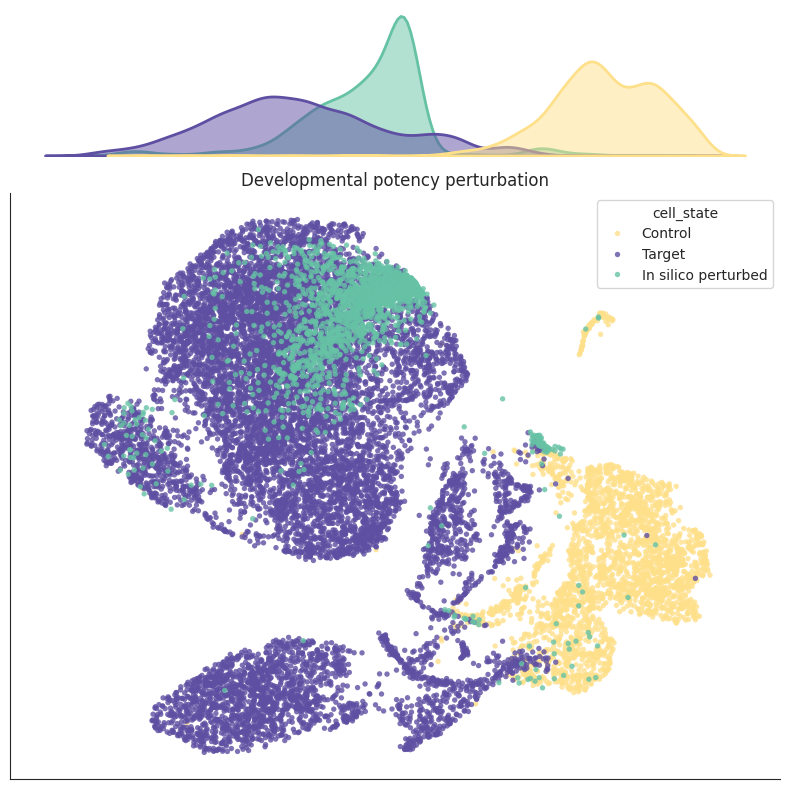

Saved perturbation figure to: /home/mcb/users/hchen26/method/textgrad/LLM-ITL-main/scConcept_github/Results/Mouse_neurogenesis_10x_cytotrace2/perturbation_Mouse_neurogenesis_10x_cytotrace2_fold64.pdf


In [65]:
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

# =========================================================
# Project perturbed cells into the reference UMAP space
# =========================================================
# The reference space is learned from:
# - original source cells
# - original target cells
#
# The perturbed source cells are then projected into the same space.

pca = PCA(n_components=50, random_state=0)

X_reference_pca = pca.fit_transform(adata_reference.X)

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.5,
    random_state=42,
    verbose=True
)

reference_umap = umap_model.fit_transform(X_reference_pca)

X_perturbed_pca = pca.transform(adata_perturbed.X)
perturbed_umap = umap_model.transform(X_perturbed_pca)

all_umap = np.vstack([reference_umap, perturbed_umap])

all_batches = (
    reference_labels
    + ["In silico perturbed"] * adata_perturbed.n_obs
)

# =========================================================
# Build visualization dataframe
# =========================================================

umap_df = pd.DataFrame({
    "UMAP1": all_umap[:, 1],
    "UMAP2": all_umap[:, 0],
    "cell_state": all_batches
})

# =========================================================
# Plot UMAP with marginal KDE
# =========================================================

plt.rcdefaults()
sns.reset_defaults()
sns.set_style("white")

state_order = [
    "Control",
    "Target",
    "In silico perturbed"
]

palette = {
    "Control": "#FEE08B",
    "Target": "#5E4FA2",
    "In silico perturbed": "#66C2A5",
}

fig = plt.figure(figsize=(8, 8))
grid = fig.add_gridspec(2, 1, height_ratios=[1, 4])

# Main UMAP scatter plot
ax_scatter = fig.add_subplot(grid[1])

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="cell_state",
    hue_order=state_order,
    palette=palette,
    s=15,
    alpha=0.8,
    edgecolor="none",
    legend=True,
    ax=ax_scatter
)

ax_scatter.invert_xaxis()
ax_scatter.tick_params(
    left=False,
    bottom=False,
    labelleft=False,
    labelbottom=False
)

ax_scatter.set_xlabel("")
ax_scatter.set_ylabel("")
ax_scatter.set_title("Developmental potency perturbation")

ax_scatter.spines["top"].set_visible(False)
ax_scatter.spines["right"].set_visible(False)

# Top KDE plot
ax_kde = fig.add_subplot(grid[0], sharex=ax_scatter)

sns.kdeplot(
    data=umap_df,
    x="UMAP1",
    hue="cell_state",
    hue_order=state_order,
    palette=palette,
    fill=True,
    linewidth=2.0,
    common_norm=False,
    legend=False,
    alpha=0.5,
    ax=ax_kde
)

ax_kde.set_axis_off()

plt.tight_layout()

# =========================================================
# Save figure
# =========================================================

results_dir = PROJECT_ROOT / "Results" / dataset_name
results_dir.mkdir(parents=True, exist_ok=True)

figure_file = results_dir / f"perturbation_{dataset_name}_fold64.pdf"

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Saved perturbation figure to: {figure_file}")